# Ejercicio Formativo 3 Capítulo 3

## Importando librerias

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


## Misión 1: Preparación de los datos

In [14]:
df = pd.read_csv('E3_datos.csv')
display(df.head())
df.shape

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


(20640, 10)

* **Limpieza de datos**:
Completar valores numéricos faltantes usando promedios y eliminar filas con datos faltantes en columnas categóricas.\
(Recordemos que las variables categóricas, son literalmente categorías y no valores numéricos)

In [15]:
df.dtypes

,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,object


In [16]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [17]:
media = df['total_bedrooms'].mean()
df['total_bedrooms'] = df['total_bedrooms'].fillna(media)
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


## Misión 2: Análisis visual

El análisis se basa en las relaciones entre las características y el valor medio de las viviendas (median_house_value), que utilizaremos como el color de los marcadores.
* Vamos a hacer gráficos de dispersión entre diferentes pares de variables

* Por ejemplo, analizamos la relación entre medianIncome (Ingreso medio) y medianHouseValue (Valor de la vivienda)

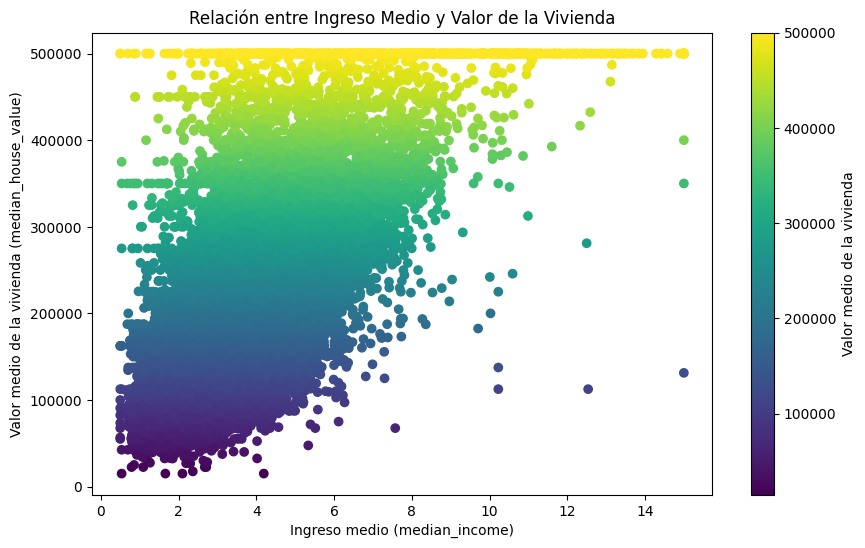

In [20]:
plt.figure(figsize=(10, 6))
# Crear gráfico de dispersión con color basado en median_house_value
sc = plt.scatter(df['median_income'], df['median_house_value'],
                 c=df['median_house_value'], cmap='viridis')

# Agregar barra de colores y etiquetas
plt.colorbar(sc, label='Valor medio de la vivienda')
plt.xlabel('Ingreso medio (median_income)')
plt.ylabel('Valor medio de la vivienda (median_house_value)')
plt.title('Relación entre Ingreso Medio y Valor de la Vivienda')

# Mostrar gráfico
plt.show()


Este gráfico muestra la relación entre el ingreso medio (median_income) y el valor de las viviendas (median_house_value). Cada punto representa un distrito, y el color indica el valor medio de las viviendas en ese distrito.

* Grupos: Se observa una relación positiva, donde un mayor ingreso medio tiende a asociarse con un mayor valor de las viviendas. Los distritos con mayor ingreso muestran casas de mayor valor (colores más oscuros).


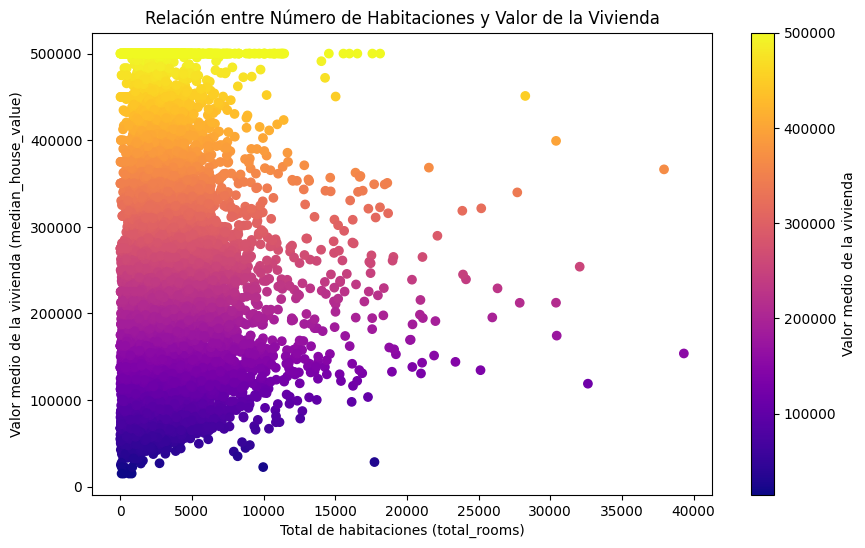

In [21]:
plt.figure(figsize=(10, 6))
# Crear gráfico de dispersión para total_rooms vs median_house_value
sc = plt.scatter(df['total_rooms'], df['median_house_value'],
                 c=df['median_house_value'], cmap='plasma')

# Agregar barra de colores y etiquetas
plt.colorbar(sc, label='Valor medio de la vivienda')
plt.xlabel('Total de habitaciones (total_rooms)')
plt.ylabel('Valor medio de la vivienda (median_house_value)')
plt.title('Relación entre Número de Habitaciones y Valor de la Vivienda')

# Mostrar gráfico
plt.show()


Análisis: Aquí se muestra la relación entre el número total de habitaciones en un distrito (total_rooms) y el valor de las viviendas (median_house_value).
* En este gráfico, no se observa una relación lineal clara entre el número de habitaciones y el valor de las viviendas. Podría sugerir que el tamaño o número de habitaciones no es un predictor tan fuerte del valor de la vivienda como lo es el ingreso medio.

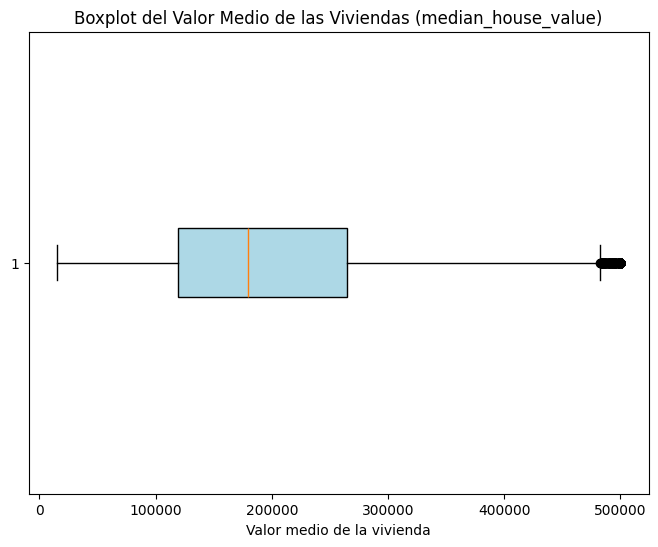

In [22]:
plt.figure(figsize=(8, 6))
# Crear boxplot para el valor medio de las viviendas
plt.boxplot(df['median_house_value'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='lightblue'))

plt.title('Boxplot del Valor Medio de las Viviendas (median_house_value)')
plt.xlabel('Valor medio de la vivienda')
plt.show()

Análisis: El boxplot te permite visualizar la distribución del valor medio de las viviendas y buscar valores atípicos (outliers).
* En este gráfico, cualquier punto que esté muy alejado de la caja central (rango intercuartil) será considerado un outlier. Los valores muy altos o muy bajos que se encuentran fuera de este rango representan distritos con precios de viviendas atípicos, comparados con el resto de los distrito

## Misión 3: Análisis de clusters

Paso 1: Preparación de los datos para clustering.


Primero necesitamos preparar los datos de dos formas diferentes:

- Espacio de características (sin etiqueta): Usaremos solo las características numéricas.
- Espacio completo (con la etiqueta): Aquí añadiremos la etiqueta (median_house_value) como una característica más.

Aseguramos que los datos numéricos estén correctamente normalizados, ya que el clustering con K-means se ve afectado por la escala de las características.

In [24]:
# Seleccionamos las características numéricas
features = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

# Normalizamos las características numéricas
scaler = StandardScaler()
X_features = scaler.fit_transform(df[features])

# También incluimos la etiqueta en un segundo conjunto
X_complete = scaler.fit_transform(df[features + ['median_house_value']])

Paso 2: Método del codo para encontrar el número óptimo de clusters.


Para encontrar el número óptimo de clusters, usaremos el método del codo, que mide la "inercia" o "dentro del grupo suma de cuadrados" para diferentes números de clusters y selecciona el valor donde la inercia comienza a disminuir de manera menos pronunciada.

2.1 Clustering sobre el espacio de características (sin la etiqueta):

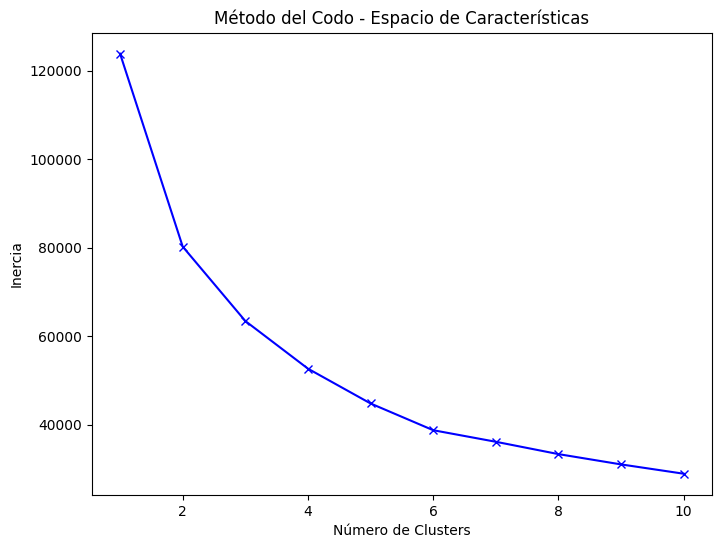

In [26]:
# Probar varios números de clusters
inertia = []
K_range = range(1, 11)  # Probar entre 1 y 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_features)
    inertia.append(kmeans.inertia_)

# Gráfico del método del codo
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo - Espacio de Características')
plt.show()


# Método del codo para identificar el número óptimo de clusters
# Inercia representa la suma de las distancias cuadradas de cada punto a su centroide más cercano.
# Cuanto menor es la inercia, más compactos están los clusters.

2.2 Clustering sobre el espacio completo (con la etiqueta):

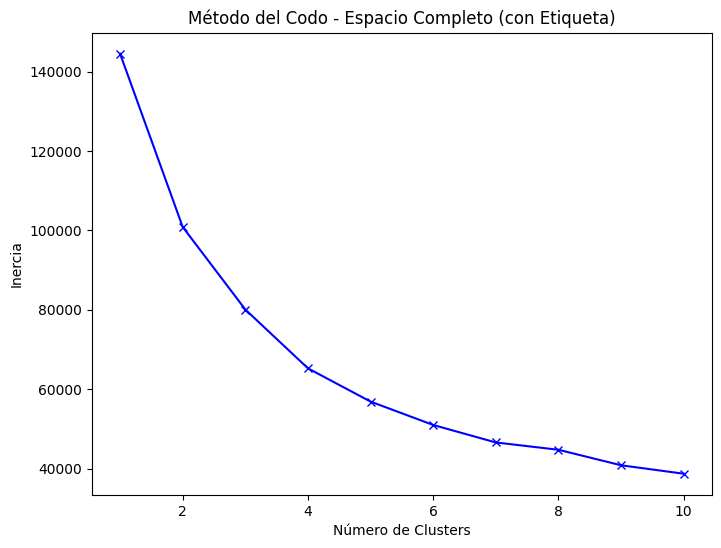

In [27]:
inertia_complete = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_complete)
    inertia_complete.append(kmeans.inertia_)

# Gráfico del método del codo
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia_complete, 'bx-')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo - Espacio Completo (con Etiqueta)')
plt.show()

Paso 3: Aplicar el clustering óptimo.

Una vez que hayas identificado el número óptimo de clusters (normalmente donde el gráfico del codo empieza a doblarse), podemos aplicar K-means para ese número de clusters.

3.1 Clustering con el número óptimo sobre el espacio de características:

In [28]:
# Asumamos que el número óptimo es 4 (cambiar según el gráfico del codo)
optimal_k = 4

kmeans_features = KMeans(n_clusters=optimal_k, random_state=0)
clusters_features = kmeans_features.fit_predict(X_features)

# Agregar las etiquetas de cluster a los datos originales
df['cluster_features'] = clusters_features

3.2 Clustering con el número óptimo sobre el espacio completo:

In [29]:
kmeans_complete = KMeans(n_clusters=optimal_k, random_state=0)
clusters_complete = kmeans_complete.fit_predict(X_complete)

# Agregar las etiquetas de cluster al espacio completo
df['cluster_complete'] = clusters_complete

Paso 4: Visualización de los clusters.

Ahora visualizaremos los clusters para comparar cómo cambian cuando usamos el espacio de características sin la etiqueta vs. con la etiqueta.

4.1 Visualización del clustering en el espacio de características:

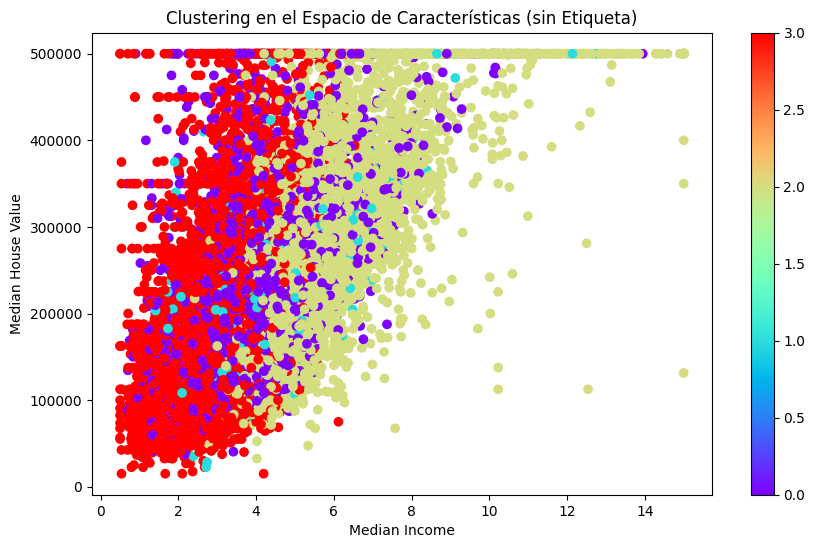

In [33]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(df['median_income'], df['median_house_value'], c=df['cluster_features'], cmap='rainbow')
plt.colorbar(sc)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Clustering en el Espacio de Características (sin Etiqueta)')
plt.show()

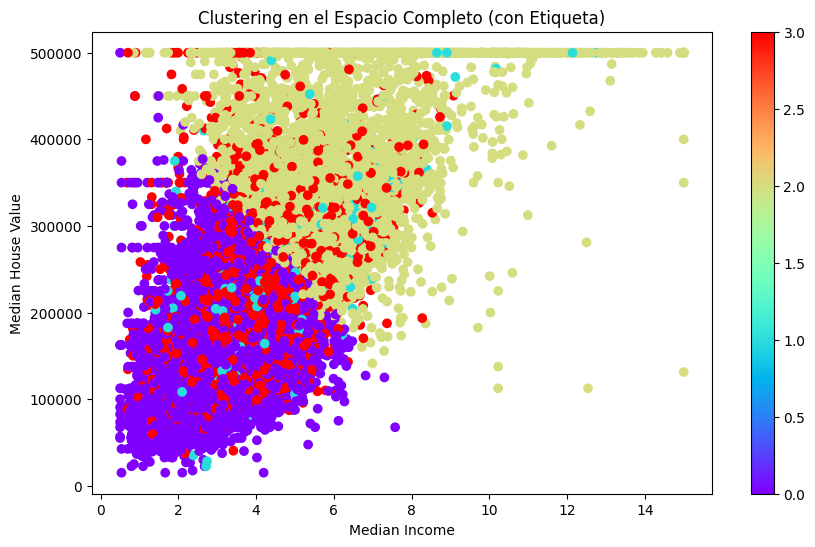

In [34]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(df['median_income'], df['median_house_value'], c=df['cluster_complete'], cmap='rainbow')
plt.colorbar(sc)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Clustering en el Espacio Completo (con Etiqueta)')
plt.show()

* En ambos análisis de clusters, se pueden observar agrupaciones de datos basadas en ciertas características, como median_income y median_house_value, que ayudan a diferenciar los distritos de acuerdo con el valor de las viviendas.
* El clustering basado en el espacio de características tiende a agrupar los datos en función de las variables sin influencia directa de la etiqueta (median_house_value), creando grupos que reflejan las diferencias en características como el ingreso o el número de habitaciones.
#### Diferencias:
* El clustering en el espacio completo (con la etiqueta) probablemente agrupe de manera más marcada las viviendas de alto valor en un cluster distinto. Esto ocurre porque la etiqueta influye directamente en el proceso de clustering, haciendo que los datos se agrupen de acuerdo con los valores de las viviendas más que solo en base a las características subyacentes.
* En el clustering sin la etiqueta, puede haber más solapamiento entre los grupos de datos, ya que se basa solo en las características.
#### Conclusión:
El uso de la etiqueta en el clustering tiende a generar grupos más definidos en función del precio de las viviendas, lo que resalta cómo la inclusión de la variable objetivo afecta el proceso.
Sin la etiqueta, los clusters están más dispersos y tienden a reflejar las diferencias entre las características subyacentes, sin un enfoque específico en el precio de las viviendas.

## Misión 4: Predicción de la etiqueta

### 1: Predicción Tradicional

Entrenaremos modelos predictivos para predecir directamente la etiqueta (median_house_value), utilizando tres familias distintas de modelos.

Para este caso, vamos a probar tres familias distintas de modelos:

* Regresión Lineal (LinearRegression)
* Árbol de Decisión (DecisionTreeRegressor)
* Random Forest (RandomForestRegressor)

Dividir los datos en entrenamiento y prueba
* Usamos la columna median_house_value como etiqueta y las demás columnas numéricas como características.

In [36]:
# Separar las características y la etiqueta
X = df[['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']]
y = df['median_house_value']

# Dividir los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Paso 2: Entrenamiento de los modelos


* 2.1 Regresión Lineal


In [38]:
# Entrenar el modelo
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Hacer predicciones
y_pred_lin = lin_reg.predict(X_test)

# Evaluar el rendimiento
mse_lin = mean_squared_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print(f"Regresión Lineal - MSE: {mse_lin}, R2: {r2_lin}")

Regresión Lineal - MSE: 5963976459.533631, R2: 0.5448767095949154



* 2.2 Árbol de Decisión

In [40]:
# Entrenar el modelo
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train, y_train)

# Hacer predicciones
y_pred_tree = tree_reg.predict(X_test)

# Evaluar el rendimiento
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print(f"Árbol de Decisión - MSE: {mse_tree}, R2: {r2_tree}")

Árbol de Decisión - MSE: 9105555638.32849, R2: 0.3051363513586548


* 2.3 Random Forest

In [43]:
# Entrenar el modelo
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train, y_train)

# Hacer predicciones
y_pred_forest = forest_reg.predict(X_test)

# Evaluar el rendimiento
mse_forest = mean_squared_error(y_test, y_pred_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print(f"Random Forest - MSE: {mse_forest}, R2: {r2_forest}")

Random Forest - MSE: 4812351673.215778, R2: 0.6327595618525214


### 2: Predicción con Reducción de Dimensionalidad

Usaremos PCA (Análisis de Componentes Principales) para reducir las dimensiones de los datos y entrenaremos los modelos en espacios reducidos.

 #### Aplicar PCA
Probaremos con 3 tamaños diferentes de espacios de características reducidos: 2, 3 y 5 componentes

In [45]:
# Reducción a 2 componentes
pca_2 = PCA(n_components=2)
X_train_pca_2 = pca_2.fit_transform(X_train)
X_test_pca_2 = pca_2.transform(X_test)

# Reducción a 3 componentes
pca_3 = PCA(n_components=3)
X_train_pca_3 = pca_3.fit_transform(X_train)
X_test_pca_3 = pca_3.transform(X_test)

# Reducción a 5 componentes
pca_5 = PCA(n_components=5)
X_train_pca_5 = pca_5.fit_transform(X_train)
X_test_pca_5 = pca_5.transform(X_test)


Paso 2: Entrenamiento de modelos en los espacios reducidos

 Regresión Lineal, Árbol de Decisión y Random Forest en cada uno de estos espacios.

2.1 Regresión Lineal con 2 componentes

In [46]:
lin_reg.fit(X_train_pca_2, y_train)
y_pred_pca_2 = lin_reg.predict(X_test_pca_2)
mse_pca_2 = mean_squared_error(y_test, y_pred_pca_2)
r2_pca_2 = r2_score(y_test, y_pred_pca_2)
print(f"Regresión Lineal con 2 componentes - MSE: {mse_pca_2}, R2: {r2_pca_2}")


Regresión Lineal con 2 componentes - MSE: 12006075596.239103, R2: 0.08379171727317347


2.2 Árbol de Decisión con 3 componentes

In [47]:
tree_reg.fit(X_train_pca_3, y_train)
y_pred_pca_3 = tree_reg.predict(X_test_pca_3)
mse_pca_3 = mean_squared_error(y_test, y_pred_pca_3)
r2_pca_3 = r2_score(y_test, y_pred_pca_3)
print(f"Árbol de Decisión con 3 componentes - MSE: {mse_pca_3}, R2: {r2_pca_3}")


Árbol de Decisión con 3 componentes - MSE: 18235917640.229893, R2: -0.39162032182577766


2.3 Random Forest con 5 componentes

In [48]:
forest_reg.fit(X_train_pca_5, y_train)
y_pred_pca_5 = forest_reg.predict(X_test_pca_5)
mse_pca_5 = mean_squared_error(y_test, y_pred_pca_5)
r2_pca_5 = r2_score(y_test, y_pred_pca_5)
print(f"Random Forest con 5 componentes - MSE: {mse_pca_5}, R2: {r2_pca_5}")


Random Forest con 5 componentes - MSE: 8257284594.481747, R2: 0.3698696566039733


Según los resultados, el modelo Random Forest entrenado con el espacio de características completo tuvo el mejor rendimiento con un MSE (error cuadrado medio mas bajo, mas cercano a valores reales) de 4812351673.21 y un R² de 0.63276. Ahora procederemos a realizar un proceso de selección de características para construir un ranking de las más informativas.

## Misión 5: Ranking de mejores características

### Paso 1: Entrenar el modelo de Random Forest
Usaremos el modelo de Random Forest que ya obtuviste, pero agregaremos un análisis de importancia de características. Random Forest tiene un atributo llamado feature_importances_ que mide la importancia de cada característica.

In [49]:
# Entrenar el modelo nuevamente (si es necesario)
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train, y_train)

# Obtener las importancias de las características
importances = forest_reg.feature_importances_

# Crear un DataFrame para organizar las importancias
feature_names = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Ordenar las características por importancia
importance_df = importance_df.sort_values(by='Importance', ascending=False)
print(importance_df)


              Feature  Importance
5       median_income    0.565650
3          population    0.104195
0  housing_median_age    0.098074
2      total_bedrooms    0.089217
1         total_rooms    0.073188
4          households    0.069675


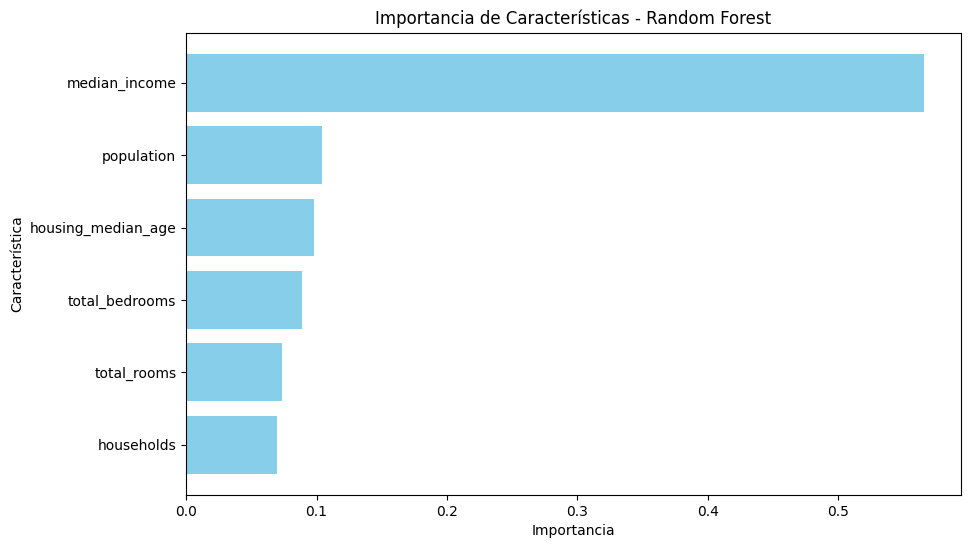

In [50]:
# Visualización de la importancia de las características
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Importancia de Características - Random Forest')
plt.gca().invert_yaxis()  # Invertir el eje para que la característica más importante aparezca arriba
plt.show()


## Misión 6: Nuevas características

1. Carga de las nuevas características: Vamos a incluir las columnas longitude y latitude en el análisis.

2. Repetición de la limpieza de datos: Aplicaremos los mismos procesos de limpieza, como el manejo de valores faltantes, con las nuevas variables.

3. Repetición del análisis de visualización y clusters: Realizaremos gráficos de dispersión y clustering, incluyendo longitude y latitude.

4. Repetición de la predicción con las nuevas variables: Entrenaremos los modelos predictivos (Regresión Lineal, Árbol de Decisión y Random Forest) y verificaremos cómo afectan las nuevas características al rendimiento.

In [52]:
# Verifica si longitude y latitude están en el DataFrame
if 'longitude' in df.columns and 'latitude' in df.columns:
    print('Longitude y Latitude ya están en los datos.')
else:
    print('No se encuentran las columnas longitude y latitude.')

# Verifica valores faltantes en longitude y latitude
nan_counts_new = df[['longitude', 'latitude']].isna().sum()
print(f"Valores NaN en longitude y latitude: \n{nan_counts_new}")

# Rellenar valores faltantes en longitude y latitude con la media (si hay NaN)
means_new = df[['longitude', 'latitude']].mean()
df[['longitude', 'latitude']] = df[['longitude', 'latitude']].fillna(means_new)

# Verifica que no haya NaNs restantes
print(df[['longitude', 'latitude']].isna().sum())


Longitude y Latitude ya están en los datos.
Valores NaN en longitude y latitude: 
longitude    0
latitude     0
dtype: int64
longitude    0
latitude     0
dtype: int64


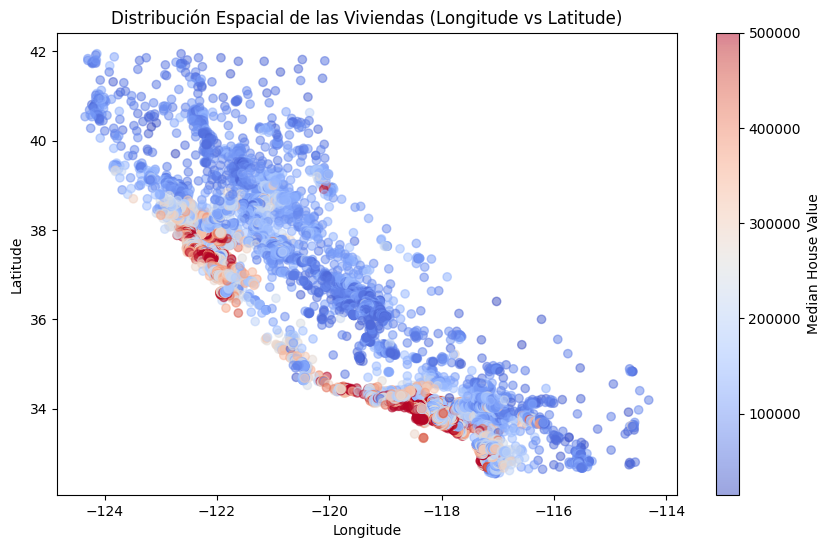

In [54]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'], cmap='coolwarm', alpha=0.5)
plt.colorbar(sc, label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Distribución Espacial de las Viviendas (Longitude vs Latitude)')
plt.show()

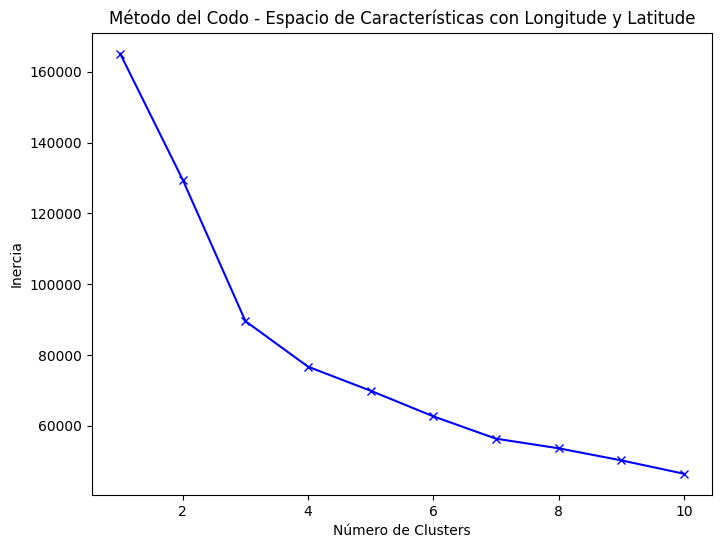

In [56]:
# Añadir longitude y latitude a las características
features_new = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'longitude', 'latitude']

# Normalizamos las características numéricas
scaler = StandardScaler()
X_features_new = scaler.fit_transform(df[features_new])

# Método del codo para encontrar el número óptimo de clusters
inertia_new = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_features_new)
    inertia_new.append(kmeans.inertia_)

# Gráfico del método del codo con las nuevas características
plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia_new, 'bx-')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo - Espacio de Características con Longitude y Latitude')
plt.show()


In [58]:
# Separar las características y la etiqueta (incluyendo longitude y latitude)
X_new = df[features_new]
y = df['median_house_value']

# Dividir los datos en entrenamiento y prueba
X_train_new, X_test_new, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

# Entrenar y evaluar los modelos con las nuevas características

# Regresión Lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train_new, y_train)
y_pred_lin_new = lin_reg.predict(X_test_new)
mse_lin_new = mean_squared_error(y_test, y_pred_lin_new)
r2_lin_new = r2_score(y_test, y_pred_lin_new)
print(f"Regresión Lineal - MSE: {mse_lin_new}, R2: {r2_lin_new}")

# Árbol de Decisión
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_new, y_train)
y_pred_tree_new = tree_reg.predict(X_test_new)
mse_tree_new = mean_squared_error(y_test, y_pred_tree_new)
r2_tree_new = r2_score(y_test, y_pred_tree_new)
print(f"Árbol de Decisión - MSE: {mse_tree_new}, R2: {r2_tree_new}")

# Random Forest
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train_new, y_train)
y_pred_forest_new = forest_reg.predict(X_test_new)
mse_forest_new = mean_squared_error(y_test, y_pred_forest_new)
r2_forest_new = r2_score(y_test, y_pred_forest_new)
print(f"Random Forest - MSE: {mse_forest_new}, R2: {r2_forest_new}")


Regresión Lineal - MSE: 5052953703.901626, R2: 0.6143987268246026
Árbol de Decisión - MSE: 4887352045.346172, R2: 0.6270361294451003
Random Forest - MSE: 2487911386.756345, R2: 0.810142373253873


              Feature  Importance
5       median_income    0.520714
6           longitude    0.156237
7            latitude    0.146104
0  housing_median_age    0.065976
3          population    0.037807
2      total_bedrooms    0.028402
1         total_rooms    0.024685
4          households    0.020074


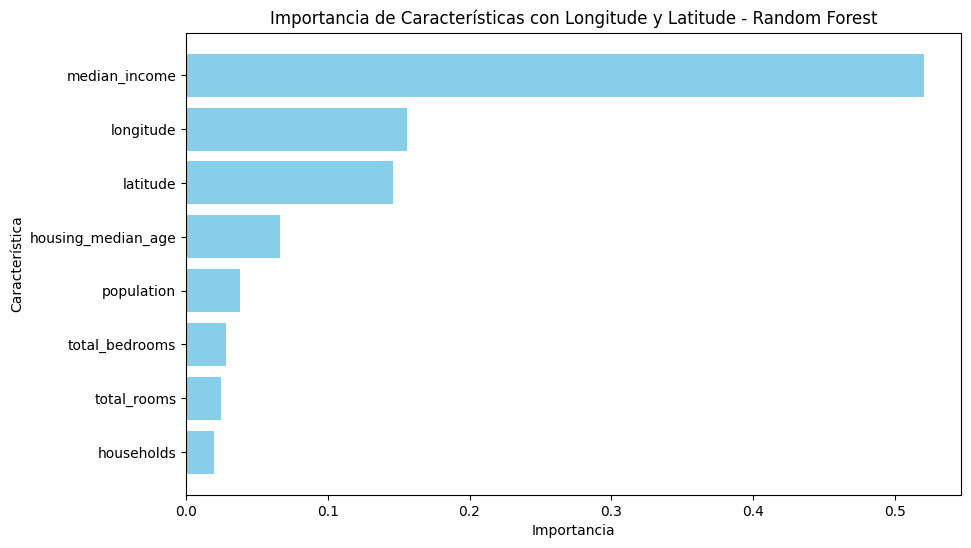

In [59]:
# Importancia de las características con longitude y latitude
importances_new = forest_reg.feature_importances_

# Crear un DataFrame para organizar las importancias
importance_df_new = pd.DataFrame({'Feature': features_new, 'Importance': importances_new})

# Ordenar las características por importancia
importance_df_new = importance_df_new.sort_values(by='Importance', ascending=False)
print(importance_df_new)

# Visualizar la importancia de las características
plt.figure(figsize=(10, 6))
plt.barh(importance_df_new['Feature'], importance_df_new['Importance'], color='skyblue')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.title('Importancia de Características con Longitude y Latitude - Random Forest')
plt.gca().invert_yaxis()
plt.show()


Influencia espacial: Al agregar longitude y latitude, es probable que los modelos detecten patrones geográficos que no eran evidentes antes.
Cambio en la importancia: Esperamos que longitude y latitude sean importantes en la predicción, especialmente si hay una fuerte correlación espacial con los precios de las viviendas.
Mejora en la predicción: Es posible que los modelos mejoren su rendimiento (mayor R² y menor MSE) al tener en cuenta la ubicación geográfica.